> **Recommended: run this notebook in Google Colab, nothing to install.**
>
> [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/01-setup-and-quicktest.ipynb)
>
> In Colab the notebook opens without results: run the cells yourself, from
> the top (Shift+Enter runs one cell). The results shown on the documentation
> website come from a run made in advance.

# 1. Test set-up

What the complete workshop covers, and how to run these notebooks either on Google
Colab or on your own machine, are on the
[workshop overview page](https://github.com/zerocarbonshipping/navigate-zcs/blob/dev-workshop/docs/workshop/index.md). Start there if you have not read it
yet.

This first notebook installs Navigate and checks your environment on a
simulation that finishes in seconds.

## Setup

On Google Colab or in Jupyter, click **Run** on the next cell to install
Navigate. It works in either environment, and you can re-run it if you come
back to a Colab session that has gone idle.

In [1]:
import os
import sys
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path


# The branch these notebooks live on, and the one Colab clones. The "Open in
# Colab" badge at the top of the notebook, like the links between the
# notebooks, opens the copy on the workshop-colab branch instead: the same
# notebooks with their outputs cleared, rebuilt from this branch by
# .github/workflows/workshop-colab.yml. Change BRANCH, and that workflow, to
# "main" once the branch has been merged.
BRANCH = "dev-workshop"


def at_repo_root() -> bool:
    """True if the working directory is the root of the repository."""
    return Path("navigate").is_dir() and Path("assumptions").is_dir()


if at_repo_root():
    print("Already at the repository root.")
elif Path("../../navigate").is_dir():
    # Local Jupyter starts the kernel in the notebook's own folder,
    # docs/workshop/, but the paths in these notebooks are relative to the root.
    os.chdir("../..")
    print("Moved up to the repository root.")
else:
    # Colab, or any other fresh environment
    if not Path("navigate-zcs").is_dir():
        !git clone --depth 1 -b {BRANCH} https://github.com/zerocarbonshipping/navigate-zcs.git
    os.chdir("navigate-zcs")
    print("Cloned the repository and moved into it.")

assert at_repo_root(), f"not at the repository root: {Path.cwd()}"

# Install Navigate unless it is genuinely installed. `import navigate` is not a
# usable test here: from the repository root it succeeds because the source
# folder is present, which leaves the `navigate` command itself missing.
try:
    print(f"Navigate {version('navigate-zcs')} is already installed.")
except PackageNotFoundError:
    %pip install -q .
    print("Installed Navigate.")

!"{sys.executable}" -m navigate --help

Moved up to the repository root.
Navigate 1.0.0 is already installed.


usage: Navigate [-h] [-p] [-e] [-s] [-l {DEBUG,INFO,WARNING,ERROR}] [-d DIR]
                [--solver {auto,gurobi,highs}] [-r PATH]
                [PATH]

positional arguments:
  PATH                  Path to the .nav simulation deck to run. When combined
                        with --replot, an optional .inc file with Plot node(s)
                        to use instead of the plot nodes stored in the plot
                        data.

options:
  -h, --help            show this help message and exit
  -p, --profile         Profile the computational performance of the
                        simulation. Note that this suppresses all output that
                        is not directly related to the simulation.
  -e, --export-assumptions
                        Export Assumptions in an Excel format.
  -s, --suppress-plots  Suppress the generation of plots at the end of the
                        simulation. Note that Excel based output reports will
                        still be 

## Quick test: a minimal single-vessel deck

The cell below writes a deck that reproduces the minimal single-vessel example
from [Tutorial 1](https://zerocarbonshipping.github.io/navigate-zcs/tutorials/tutorial_1.html): one vessel, one fuel and one port, run from
2025 to 2050 to confirm that your environment works. It asks for one of that
tutorial's three plots, since one is enough to show the run worked.

For a little context from Tutorial 1, a **deck** is the input to a Navigate run:
one `.nav` file, plus the `.inc` files it includes. Navigate is the program, and
the deck is the instructions you hand it. Every `.nav` file has the same two
sections:

- `DEFINE` sets out the nodes the simulation is made of: vessels, fuels, ports,
  routes, regulations and so on. A **node** is one declared thing, written as a
  type, a name in quotes, and a block of attributes.
- `EVENTS` sets out the timeline: the dates the model steps through, and any
  changes to nodes along the way.

In [2]:
import os

base = "quicktest"
inc_dir = os.path.join(base, "includes")
os.makedirs(inc_dir, exist_ok=True)

with open(os.path.join(base, "quicktest.nav"), "w") as f:
    f.write('''DEFINE {
    Include "./includes/define.inc"
}

EVENTS {
    Include "./includes/events.inc"
}
''')

with open(os.path.join(inc_dir, "define.inc"), "w") as f:
    f.write('''ModelDefinition {
    StartDate = "01/01/2025"
}

Fleet "fleet" {
    Vessels = [Vessel("vessel_ice_oil")]
    InterFuelSensitivity = 0.5
    IntraFuelSensitivity = 0.5
    InitialVessels = 100
}

Vessel "vessel_ice_oil" {
    PowerSystem = PowerSystem("ice_oil")
    Route = Route("route")
    NominalCapacity = 8000
    Tanks = [Tank("main_oil")]
    PropulsionLoad = 10
}

PowerSystem "ice_oil" {
    Propulsion = Converter("propulsion_ice_oil")
    Electrical = Converter("electrical_ice_oil")
    Heat = Converter("heat_boiler_oil")
}

Converter "propulsion_ice_oil" {
    PowerCapacity = 50
    MainFuelTypes = OIL
    Efficiency = 0.5
}

Converter "electrical_ice_oil" {
    PowerCapacity = 10
    MainFuelTypes = OIL
    Efficiency = 0.5
}

Converter "heat_boiler_oil" {
    PowerCapacity = 5
    MainFuelTypes = OIL
    Efficiency = 0.5
}

Tank "main_oil" {
    FuelTypes = OIL
    Size = 9000
}

Route "route" {
    RouteType = REGIONAL_TRIP
    Ports = [Port("port")]
    TimeAtSea = 0.75
    ConditionDistribution = [1.0]
    Speeds = [10]
}

Port "port" {
    set_bunker_price_overwrite("heavy_fuel_oil", 250)
    set_bunker_wtt_overwrite("heavy_fuel_oil", "carbon_dioxide", 0.62)
}

BunkerLogistics {
    LiquidMarketFuels = [Fuel("heavy_fuel_oil")]
}

Fuel "heavy_fuel_oil" {
    FuelType = OIL

    LowerHeatingValue = 41.2
    MassDensity = 0.9

    set_ttw("carbon_dioxide", 3.114)
    set_ttw("methane", 0.00005)
    set_ttw("nitrous_oxide", 0.00018)
}

Emission "carbon_dioxide" {
    GlobalWarmingPotential = 1
}

Emission "methane" {
    GlobalWarmingPotential = 25
}

Emission "nitrous_oxide" {
    GlobalWarmingPotential = 273
}

Plot "plots" {
    Directory = "./plots/"

    add_plot("global_fuel_consumed")
}
''')

lines = ["Start\n"]
for year in range(2025, 2051):
    lines.append(f'Date "01-01-{year}"\n')
lines.append("End\n")
with open(os.path.join(inc_dir, "events.inc"), "w") as f:
    f.write("".join(lines))

print("Wrote", base + "/quicktest.nav", "and includes/")


Wrote quicktest/quicktest.nav and includes/


Now let's look at the results.

If the next cell produces a plot, or at least a `Finished simulation` message
with no errors, your environment is working and you are ready to move on to
[notebook 2, the vessel case study](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/02-vessel-case-study.ipynb). The link opens it in
Colab; if you are running locally, open it from `docs/workshop/` instead.

——————————————————————————————————————————————————————————————————————————————————————————————————
            |    |    |                                  .oO
           )_)  )_)  )_)                             __/___                  _    _
          )___))___))___)\                     _____/______|              __|_|__|_|__
         )____)____)_____)\\           _______/_____\_______\_____      _|____________|__
       _____|____|____|____\\\__       \              < < <       |    |o o o o o o o o /
~~~~~~~\                   /~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        ´´´´´´´´´´´´´´´´´´´              Navigate
——————————————————————————————————————————————————————————————————————————————————————————————————
        Navigate - an integrated assessment model for decarbonizing shipping
        Developed by Fonden Mærsk Mc-Kinney Møller Center for Zero Carbon Shipping
        Version 1.0.0 - for questions, contact navigate@zerocarbonshipping.com
Da

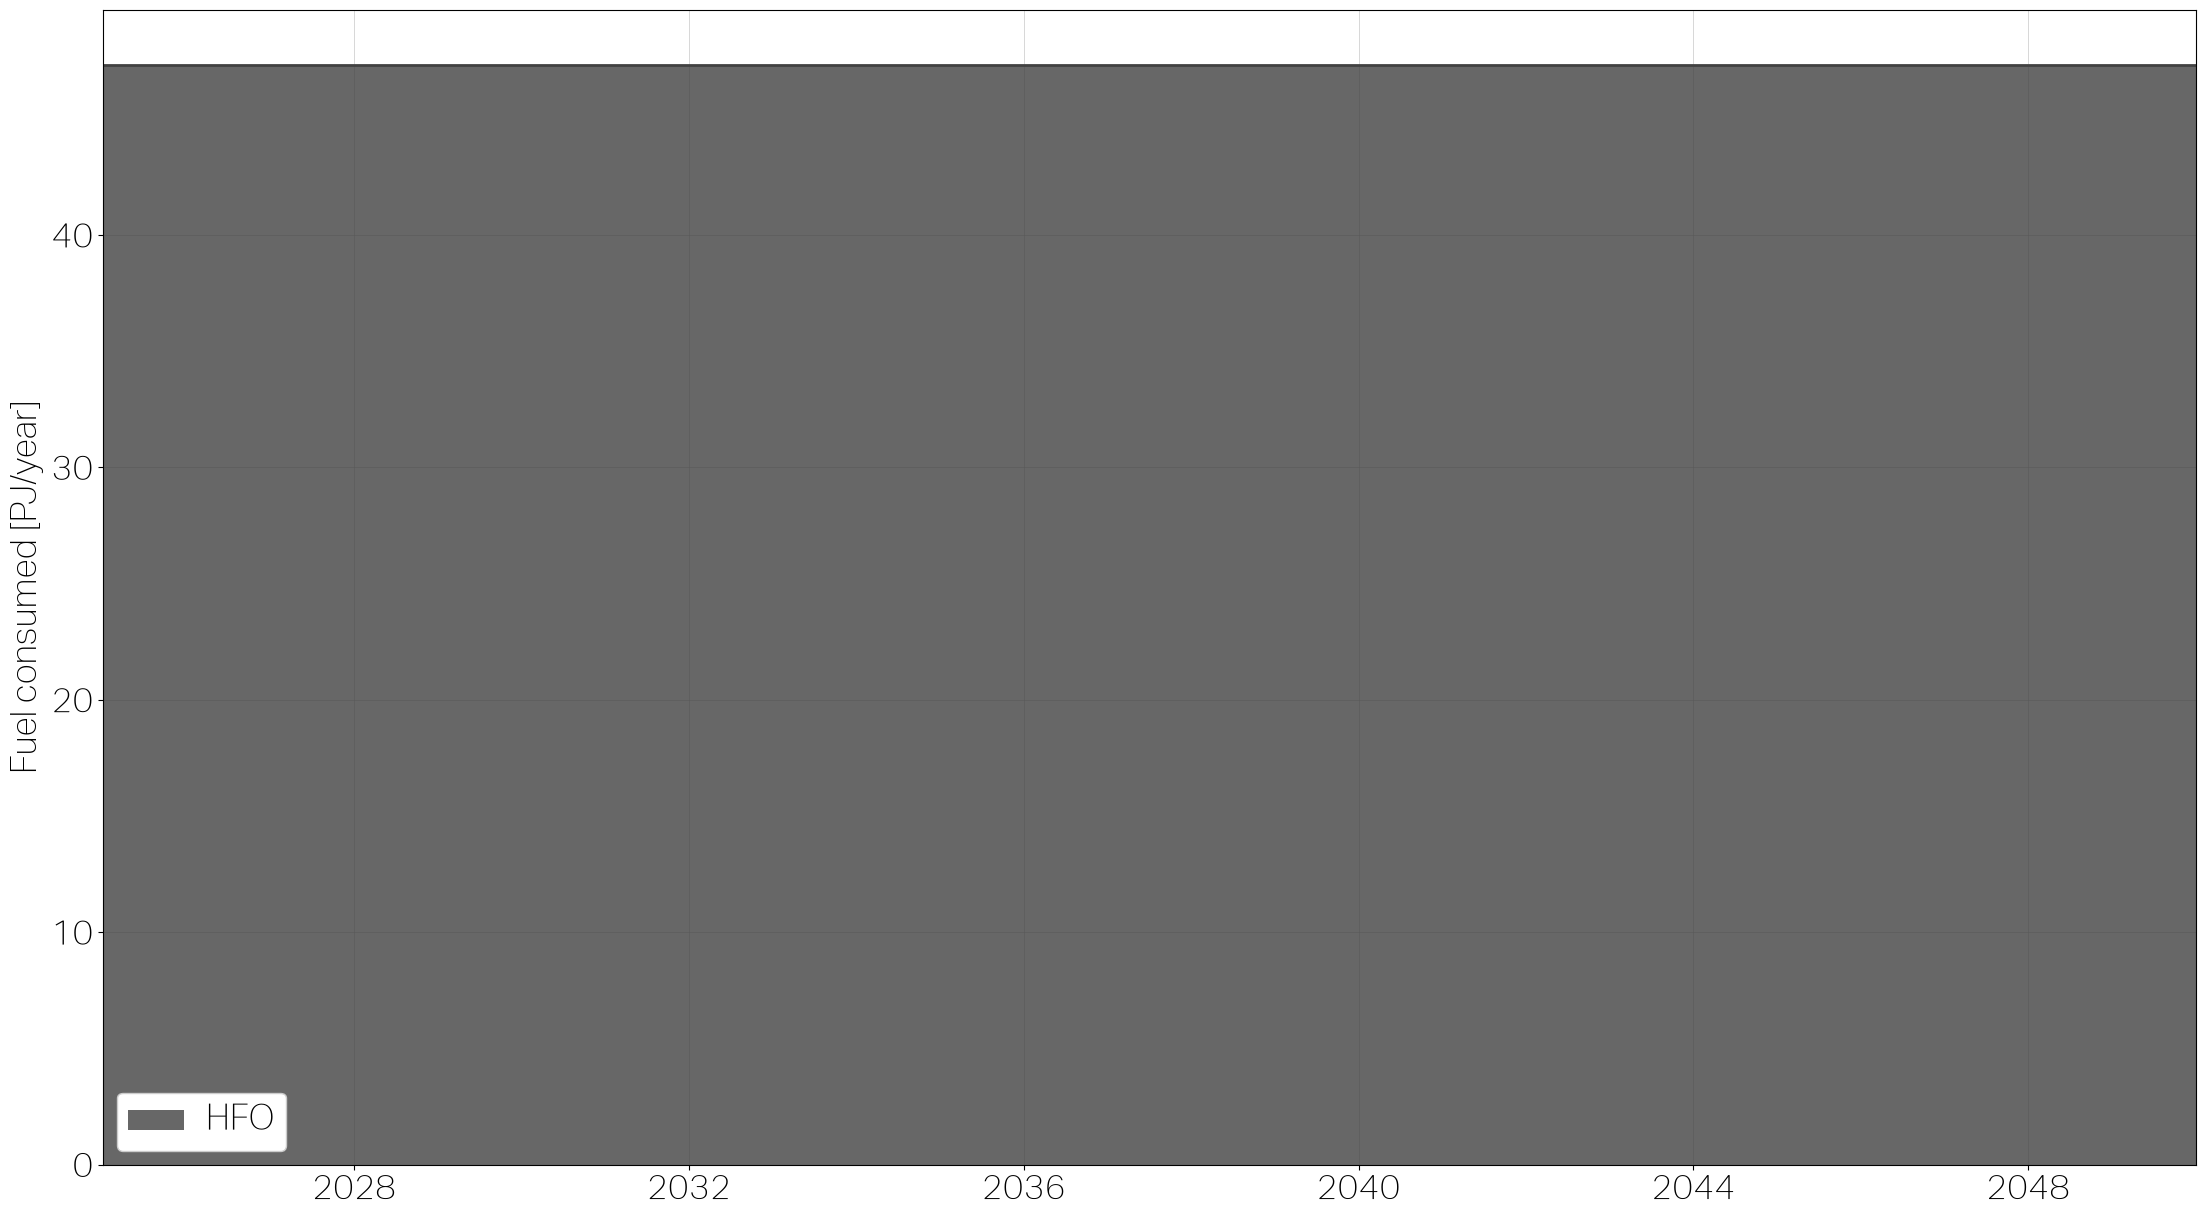

In [3]:
import sys

%cd -q quicktest
!"{sys.executable}" -m navigate quicktest.nav

from IPython.display import Image, display

# One plot: fuel consumed per year, stacked by fuel. Named explicitly rather
# than globbed, so a plot left over from an earlier run cannot show up here.
display(Image(filename="plots/global_fuel_consumed.png"))

%cd -q ..


## Workshop notebooks

**Next: [2. Illustrating the Navigate logic with a simple case](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/02-vessel-case-study.ipynb)**

Each link opens the notebook in Google Colab, in a fresh session, so run it
from the top.

1. **Test set-up** (this notebook)
2. [Illustrating the Navigate logic with a simple case](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/02-vessel-case-study.ipynb)
3. [Build your own case](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/03-build-your-own-case.ipynb) (you can read it in Colab; its prompts need Navigate installed on your own machine)
4. [Run the reference scenarios](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/04-run-a-reference-scenario.ipynb)
5. [Change the numbers and see what moves](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/05-build-your-own-whatif.ipynb)